In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Perceptron
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal width (cm)", "petal length (cm)"]].values
y = (iris.target==0)

perc = Perceptron(random_state=52)
perc.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
perc.predict(X_new)

array([ True, False])

## MLP

In [3]:
#MLP Regressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing(as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, random_state=52)

In [4]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], verbose=True, random_state=52, early_stopping=True)

In [5]:
model = make_pipeline(StandardScaler(), mlp_reg)
model.fit(X_train, y_train)

Iteration 1, loss = 0.91034429
Validation score: -0.086284
Iteration 2, loss = 0.30325176
Validation score: 0.528470
Iteration 3, loss = 0.23725859
Validation score: 0.681721
Iteration 4, loss = 0.21214956
Validation score: 0.713532
Iteration 5, loss = 0.19965349
Validation score: 0.727491
Iteration 6, loss = 0.19076315
Validation score: 0.727884
Iteration 7, loss = 0.18569666
Validation score: 0.737480
Iteration 8, loss = 0.18004090
Validation score: 0.737606
Iteration 9, loss = 0.17658083
Validation score: 0.752955
Iteration 10, loss = 0.17200692
Validation score: 0.764536
Iteration 11, loss = 0.16931752
Validation score: 0.751559
Iteration 12, loss = 0.16642969
Validation score: 0.763492
Iteration 13, loss = 0.16291738
Validation score: 0.771413
Iteration 14, loss = 0.16047071
Validation score: 0.767489
Iteration 15, loss = 0.15951169
Validation score: 0.771855
Iteration 16, loss = 0.15745830
Validation score: 0.777062
Iteration 17, loss = 0.15553740
Validation score: 0.773191
Itera

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('mlpregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[50, 50, ...]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural

In [6]:
mlp_reg.best_validation_score_

0.7995423810666894

In [7]:
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.5376083843449608

In [8]:
#MLP Classificator
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)

In [9]:
X_train = fashion_mnist.data[:60000]
y_train = fashion_mnist.target[:60000].astype(int)
X_test = fashion_mnist.data[60000:]
y_test = fashion_mnist.target[60000:].astype(int)

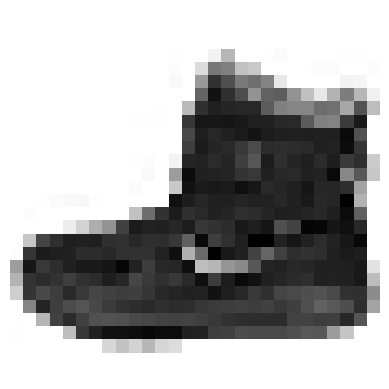

In [10]:
cloth = X_train[0].reshape(28, 28)

plt.imshow(cloth, cmap='binary')
plt.axis(False)
plt.show()

In [11]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

class_names[y_train[0]]

'Ankle boot'

In [12]:
from sklearn.preprocessing import MinMaxScaler

mlp_cls = MLPClassifier(hidden_layer_sizes=[300, 100], random_state=52, verbose=True, early_stopping=True)
mlpc_pl = make_pipeline(MinMaxScaler(), mlp_cls)

mlpc_pl.fit(X_train, y_train)

Iteration 1, loss = 0.54104692
Validation score: 0.836667
Iteration 2, loss = 0.38478353
Validation score: 0.861333
Iteration 3, loss = 0.33779805
Validation score: 0.866500
Iteration 4, loss = 0.31161091
Validation score: 0.876333
Iteration 5, loss = 0.29245055
Validation score: 0.875000
Iteration 6, loss = 0.27667604
Validation score: 0.873833
Iteration 7, loss = 0.26524335
Validation score: 0.880833
Iteration 8, loss = 0.25026319
Validation score: 0.882000
Iteration 9, loss = 0.24219645
Validation score: 0.882333
Iteration 10, loss = 0.23095393
Validation score: 0.885167
Iteration 11, loss = 0.22569667
Validation score: 0.884000
Iteration 12, loss = 0.21688705
Validation score: 0.890667
Iteration 13, loss = 0.20533544
Validation score: 0.885667
Iteration 14, loss = 0.20326613
Validation score: 0.893000
Iteration 15, loss = 0.19438656
Validation score: 0.890333
Iteration 16, loss = 0.19013545
Validation score: 0.887500
Iteration 17, loss = 0.18185399
Validation score: 0.893500
Iterat

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('minmaxscaler', ...), ('mlpclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[300, 100]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, d

In [13]:
mlpc_pl.score(X_test, y_test)

0.8896

In [14]:
X_new = X_test[:15]

print(mlpc_pl.predict(X_new))
print(mlpc_pl.predict_proba(X_new).round(3)[12])

[9 2 1 1 6 1 4 6 5 7 4 5 5 3 4]
[0.    0.    0.    0.    0.    0.9   0.    0.087 0.013 0.   ]


## Ex 10

In [2]:
from sklearn.datasets import fetch_covtype

covtype = fetch_covtype()
print(covtype.DESCR)

.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(covtype.data, covtype.target, test_size=0.1, stratify=covtype.target)

In [4]:
X_train.shape

(522910, 54)

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score

In [ ]:


mlp_cov = MLPClassifier(hidden_layer_sizes=[64, 64, 64], early_stopping=True, random_state=52)
mlp_model = make_pipeline(MinMaxScaler(), mlp_cov)

cross_val_score(mlp_model, X_train, y_train, scoring='accuracy', cv=5)

array([0.88802088, 0.89373888, 0.87806697, 0.88456905, 0.8687059 ])

In [6]:
mlp_cov = MLPClassifier(hidden_layer_sizes=[32, 32, 32, 32, 32], early_stopping=True, random_state=52)
mlp_model = make_pipeline(MinMaxScaler(), mlp_cov)

cross_val_score(mlp_model, X_train, y_train, scoring='accuracy', cv=4)

array([0.83875681, 0.86280674, 0.85836132, 0.85957759])

In [7]:
mlp_cov = MLPClassifier(hidden_layer_sizes=[64, 64, 64, 64, 64, 64], early_stopping=True, random_state=52, batch_size=32)
mlp_model = make_pipeline(MinMaxScaler(), mlp_cov)

cross_val_score(mlp_model, X_train, y_train, scoring='accuracy', cv=3)

array([0.91637025, 0.91422408, 0.9080165 ])

In [10]:
mlp_cov = MLPClassifier(hidden_layer_sizes=[64, 64, 64, 64, 64, 64, 64, 64], early_stopping=True, random_state=52, activation="tanh")
mlp_model = make_pipeline(MinMaxScaler(), mlp_cov)

cross_val_score(mlp_model, X_train[:50000], y_train[:50000], scoring='accuracy', cv=3)

array([0.8698026 , 0.85678286, 0.86517461])

In [10]:
from sklearn.preprocessing import StandardScaler

mlp_cov = MLPClassifier(hidden_layer_sizes=[200, 100, 50], early_stopping=True, random_state=52, activation="tanh")
mlp_model = make_pipeline(StandardScaler(), mlp_cov)

cross_val_score(mlp_model, X_train[:50000], y_train[:50000], scoring='accuracy', cv=3)

array([0.87568249, 0.87388252, 0.86451458])

In [11]:
mlp_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('mlpclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[200, 100, ...]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying

In [12]:
mlp_model.score(X_test, y_test)

0.9527382878386286